# Baseline Models

## Logistic Regression

In [1]:
# libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# read baseline_input
baseline_input = pd.read_csv("baseline_input.csv")

In [3]:
baseline_input.set_index('stay_id')

,icd_title,gender,race,arrival_transport,disposition,temperature,heartrate,resprate,o2sat,sbp,...,admmed_furosemide,admmed_vancomycin,admmed_pantoprazole,admmed_levothyroxine,admmed_aspirin,admmed_lorazepam,admmed_dextrose,admmed_sodium_chloride,admmed_metoprolol_tartrate,admmed_gabapentin
stay_id,,,,,,,,,,,,,,,,,,,,,
30094124,"['Weakness', 'Dehydration']",1,6,0,0,97.3,80.0,18.0,99.0,138.0,...,0,0,0,0,0,0,0,0,0,0
30225689,['Unspecified abdominal pain'],1,4,3,0,97.6,72.0,16.0,100.0,163.0,...,0,0,0,0,0,0,0,0,0,0
30279522,['Weakness'],1,6,0,0,98.2,73.0,20.0,99.0,122.0,...,0,0,0,0,1,0,0,0,0,0
30373795,"['Other specified soft tissue disorders', 'Ana...",1,6,0,2,98.1,100.0,16.0,100.0,119.0,...,0,0,1,0,1,0,0,0,0,0
30667562,"['Unsp fracture of T7-T8 vertebra, init for cl...",0,5,0,0,99.5,104.0,16.0,100.0,146.0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39740242,"['ACUTE KIDNEY FAILURE, UNSPECIFIED', 'DIABETE...",0,1,3,0,98.7,108.0,22.0,98.0,151.0,...,0,0,0,0,0,0,0,0,0,0
39747335,"['Pain in left knee', 'Chronic kidney disease,...",0,0,3,2,98.5,84.0,17.0,100.0,116.0,...,0,0,0,0,0,0,0,0,0,0
39930808,"['DIABETES UNCOMPL ADULT', 'SCHIZOAFFECTIVE-UN...",1,6,3,2,98.4,82.0,18.0,99.0,125.0,...,0,0,0,0,0,1,0,0,0,0


In [4]:
from collections import Counter
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import ast
# Work on a copy of baseline_input
df = baseline_input.copy()
df

,stay_id,icd_title,gender,race,arrival_transport,disposition,temperature,heartrate,resprate,o2sat,...,admmed_furosemide,admmed_vancomycin,admmed_pantoprazole,admmed_levothyroxine,admmed_aspirin,admmed_lorazepam,admmed_dextrose,admmed_sodium_chloride,admmed_metoprolol_tartrate,admmed_gabapentin
0,30094124,"['Weakness', 'Dehydration']",1,6,0,0,97.3,80.0,18.0,99.0,...,0,0,0,0,0,0,0,0,0,0
1,30225689,['Unspecified abdominal pain'],1,4,3,0,97.6,72.0,16.0,100.0,...,0,0,0,0,0,0,0,0,0,0
2,30279522,['Weakness'],1,6,0,0,98.2,73.0,20.0,99.0,...,0,0,0,0,1,0,0,0,0,0
3,30373795,"['Other specified soft tissue disorders', 'Ana...",1,6,0,2,98.1,100.0,16.0,100.0,...,0,0,1,0,1,0,0,0,0,0
4,30667562,"['Unsp fracture of T7-T8 vertebra, init for cl...",0,5,0,0,99.5,104.0,16.0,100.0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,39740242,"['ACUTE KIDNEY FAILURE, UNSPECIFIED', 'DIABETE...",0,1,3,0,98.7,108.0,22.0,98.0,...,0,0,0,0,0,0,0,0,0,0
122,39747335,"['Pain in left knee', 'Chronic kidney disease,...",0,0,3,2,98.5,84.0,17.0,100.0,...,0,0,0,0,0,0,0,0,0,0
123,39930808,"['DIABETES UNCOMPL ADULT', 'SCHIZOAFFECTIVE-UN...",1,6,3,2,98.4,82.0,18.0,99.0,...,0,0,0,0,0,1,0,0,0,0
124,39962121,"['Type 1 diabetes mellitus with foot ulcer', '...",1,6,3,2,98.2,117.0,20.0,100.0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
# 1) FIND TOP N ICD TITLES
N = 16
parsed_icd_lists = df['icd_title'].apply(ast.literal_eval)
all_icd_titles = [title for titles in parsed_icd_lists for title in titles]
title_counts = Counter(all_icd_titles)
top_N_titles = {title for title, _ in title_counts.most_common(N)}

# 2) CREATE df_topN
mask_has_topN = parsed_icd_lists.apply(lambda titles: any(title in top_N_titles for title in titles))
df_topN = df.loc[mask_has_topN].copy()
df_topN['icd_title'] = parsed_icd_lists.loc[mask_has_topN].apply(
    lambda titles: [title for title in titles if title in top_N_titles]
)

# 3) PRINT SUMMARY
print(f"Original df rows: {len(df)}")
print(f"df_top59 rows: {len(df_topN)}")

print("\nTop {N} ICD titles and frequencies:")
for title, freq in title_counts.most_common(59):
    print(f"{title}: {freq}")


Original df rows: 126
df_top59 rows: 65

Top {N} ICD titles and frequencies:
Long term (current) use of insulin: 14
HYPERTENSION NOS: 11
Type 2 diabetes mellitus without complications: 8
Essential (primary) hypertension: 8
DIABETES UNCOMPL ADULT: 7
Dyspnea, unspecified: 6
Unspecified atrial fibrillation: 6
Chest pain, unspecified: 5
Urinary tract infection, site not specified: 5
Type 1 diabetes mellitus without complications: 5
Acute kidney failure, unspecified: 5
Weakness: 4
Hypothyroidism, unspecified: 4
URIN TRACT INFECTION NOS: 4
ATRIAL FIBRILLATION: 4
DIABETES UNCOMPL JUVEN: 4
Dehydration: 3
Other specified soft tissue disorders: 3
PNEUMONIA,ORGANISM UNSPECIFIED: 3
ACUTE KIDNEY FAILURE, UNSPECIFIED: 3
LONG-TERM (CURRENT) USE OF INSULIN: 3
Anemia, unspecified: 3
Gastrointestinal hemorrhage, unspecified: 3
Epigastric pain: 3
Long term (current) use of anticoagulants: 3
Other fatigue: 3
Fall on same level, unspecified, initial encounter: 3
HYPERCHOLESTEROLEMIA: 3
Pure hypercholestero

In [6]:
df_topN

,stay_id,icd_title,gender,race,arrival_transport,disposition,temperature,heartrate,resprate,o2sat,...,admmed_furosemide,admmed_vancomycin,admmed_pantoprazole,admmed_levothyroxine,admmed_aspirin,admmed_lorazepam,admmed_dextrose,admmed_sodium_chloride,admmed_metoprolol_tartrate,admmed_gabapentin
0,30094124,[Weakness],1,6,0,0,97.3,80.0,18.0,99.0,...,0,0,0,0,0,0,0,0,0,0
2,30279522,[Weakness],1,6,0,0,98.2,73.0,20.0,99.0,...,0,0,0,0,1,0,0,0,0,0
3,30373795,[Type 2 diabetes mellitus without complications],1,6,0,2,98.1,100.0,16.0,100.0,...,0,0,1,0,1,0,0,0,0,0
7,30836087,"[DIABETES UNCOMPL ADULT, HYPERTENSION NOS]",0,6,3,0,98.3,77.0,16.0,97.0,...,0,1,0,1,1,0,0,0,0,0
11,31121963,"[Chest pain, unspecified]",1,4,0,0,98.8,106.0,20.0,100.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,39633384,[Long term (current) use of insulin],1,6,0,2,98.2,72.0,16.0,98.0,...,1,0,0,1,0,0,1,0,0,1
121,39740242,[DIABETES UNCOMPL JUVEN],0,1,3,0,98.7,108.0,22.0,98.0,...,0,0,0,0,0,0,0,0,0,0
123,39930808,[DIABETES UNCOMPL ADULT],1,6,3,2,98.4,82.0,18.0,99.0,...,0,0,0,0,0,1,0,0,0,0
124,39962121,[Long term (current) use of insulin],1,6,3,2,98.2,117.0,20.0,100.0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
# ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Encode icd_title using MultiLabelBinarizer
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(df_topN['icd_title'])

# 2. Prepare features
# Drop icd_title from features
X = df_topN.drop(columns=['icd_title'])

# Split into train/test sets (80/20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features using StandardScaler (fit on train, transform both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Train model
# Use OneVsRestClassifier with LogisticRegression as specified
model = OneVsRestClassifier(LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    l1_ratio=0.5,
    class_weight='balanced',
    max_iter=1000,
    random_state=42
))
model.fit(X_train_scaled, y_train)

# 4. Evaluate
# Predict on train and test
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Accuracy (note: for multi-label, accuracy is exact match; might not be ideal, but as per instruction)
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Train Accuracy: {train_accuracy}")
print(f"Test Accuracy: {test_accuracy}")


Train Accuracy: 0.9615384615384616
Test Accuracy: 0.0


In [8]:
# Confusion matrix on test set (for multi-label, this will be per-class; showing for the first class as example, or aggregate)
# Since it's multi-label, confusion matrix per class
for i, class_name in enumerate(mlb.classes_):
    print(f"\nConfusion Matrix for {class_name}:")
    cm = confusion_matrix(y_test[:, i], y_test_pred[:, i])
    print(cm)


Confusion Matrix for ATRIAL FIBRILLATION:
[[13]]

Confusion Matrix for Acute kidney failure, unspecified:
[[12  0]
 [ 1  0]]

Confusion Matrix for Chest pain, unspecified:
[[11  1]
 [ 1  0]]

Confusion Matrix for DIABETES UNCOMPL ADULT:
[[10  1]
 [ 2  0]]

Confusion Matrix for DIABETES UNCOMPL JUVEN:
[[10  1]
 [ 1  1]]

Confusion Matrix for Dyspnea, unspecified:
[[11  2]
 [ 0  0]]

Confusion Matrix for Essential (primary) hypertension:
[[8 2]
 [1 2]]

Confusion Matrix for HYPERTENSION NOS:
[[7 2]
 [3 1]]

Confusion Matrix for Hypothyroidism, unspecified:
[[12  1]
 [ 0  0]]

Confusion Matrix for Long term (current) use of insulin:
[[9 1]
 [2 1]]

Confusion Matrix for Type 1 diabetes mellitus without complications:
[[11  1]
 [ 1  0]]

Confusion Matrix for Type 2 diabetes mellitus without complications:
[[10  0]
 [ 3  0]]

Confusion Matrix for URIN TRACT INFECTION NOS:
[[11  0]
 [ 2  0]]

Confusion Matrix for Unspecified atrial fibrillation:
[[10  3]
 [ 0  0]]

Confusion Matrix for Urina

In [9]:
# Classification report on test set
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=mlb.classes_))


Classification Report (Test Set):
                                                precision    recall  f1-score   support

                           ATRIAL FIBRILLATION       0.00      0.00      0.00         0
             Acute kidney failure, unspecified       0.00      0.00      0.00         1
                       Chest pain, unspecified       0.00      0.00      0.00         1
                        DIABETES UNCOMPL ADULT       0.00      0.00      0.00         2
                        DIABETES UNCOMPL JUVEN       0.50      0.50      0.50         2
                          Dyspnea, unspecified       0.00      0.00      0.00         0
              Essential (primary) hypertension       0.50      0.67      0.57         3
                              HYPERTENSION NOS       0.33      0.25      0.29         4
                   Hypothyroidism, unspecified       0.00      0.00      0.00         0
            Long term (current) use of insulin       0.50      0.33      0.40       

In [10]:
topics_dict = {

    'sepsis & infection': [
        'septicemia nos', 'septic shock', 'sever sepsis', 'sepsis',
        'bacteremia', 'sepsis, unspecified organism',
        'cellulitis of leg', 'cellulitis of foot', 'local skin infection nos',
        'cellulitis of left lower limb', 'cellulitis of right toe', 'cellulitis of face',
        'pneumonia,organism unspecified', 'lobar pneumonia, unspecified organism',
        'pneumonia, unspecified organism', 'acute uri nos', 'infec otitis externa nos',
        'acute laryngitis, without mention of obstruction',
        'urinary tract infection, site not specified', 'urin tract infection nos',
        'unspecified viral hepatitis c without hepatic coma',
        'asymptomatic hiv infection', 'human immunodeficiency virus [hiv] disease',
    ],

    'neurological': [
        'intracerebral hemorrhage', 'nontraumatic acute subdural hemorrhage',
        'subdural hem w/o coma', 'nontraumatic subrachnoid heomrrhage, unspecified',
        'grand mal status', 'other convulsions',
        'cerebral infractoin, unspecified',
        'prsnl hx of tia (tia), and cereb infrc w/o resid deficits',
        'syncope and collapse', 'encephalopathy, unspecified', 'semicoma/stupor',
        'altered mental status',
        'alzheimer\'s disease',
        'dementia in conditions classified elsewhere without behaviroal disturbance',
        'amyotrophic lateral sclerosis', 'other conditions of brain',
        'tinnitus, left ear', 'dizziness and giddiness', 'vertigo/dizziness', 'headache',
    ],

    'cardiovascular': [
        'non-st elevation (nstemi) myocardial infraction',
        'atrial fibrillation', 'unspecified atrial fibrillation',
        'atrial flutter', 'tachycardia nos', 'cardiac arrest, cause unspecified',
        'cardiac pacemaker status', 'abn cardiovasc study nec',
        'cad unspec vessel, native or graft',
        'dissection of unspecified site of aorta', 'diss abdom aortic aneurysm',
        'congestive heart failure, unspec', 'heart failure, unspecified',
        'unsp combined systolic and diastolic (congestive) hrt fail',
        'pericardial effusion (noninflammatory)', 'acute lung edema nos',
        'shock nos', 'hypotension nos', 'hypotension, unspecified', 'respiratory arrest',
        'long term use antigoagulant', 'long term (current) use of anticoagulants',
        'abnormal coagulation profile',
    ],

    'thromboembolic disease': [
        'saddle embolus of pulmonary artery w/o acute cor pulmonale',
        'other pulmonary embolism without acute cor pulmonale',
        'acute embolism and thrombosis of deep veins of 1 up extrem',
        'thrombosis due to vascular prosth dev/grft, init',
        'portal vein thrombosis',
    ],

    'hypertension & kidney disease': [
        'essential (primary) hypertension', 'hypertension nos',
        'acute kidney failure, unspecified',
        'chronic kidney disease, stage v', 'chronic kidney disease, unspecified',
        'hyp chr kidney disease w stage 5 chr kidney disease or esrd',
        'hypertensive chronic kidney disease w stg 1-4/unsp chr kdny',
        'end stage renal disease', 'dependence on renal dialysis',
        'type 2 diabetes mellitus w diabetic chronic kidney disease',
        'displacement of surgically created av fistula, init',
    ],

    'diabetes & metabolic disorders': [
        'diabetes uncompl adult', 'diabetes uncompl juven',
        'type 1 diabetes mellitus without complications',
        'type 2 diabetes mellitus without complications',
        'diab ketoacidosis iddm', 'diab ketoacidosis adult',
        'type 1 diabetes mellitus with ketoacidosis without coma',
        'type 1 diabetes mellituts with hyperglycemia',
        'type 2 diabetes mellitus with hyperglycemia',
        'diab w manif nec adult', 'iddm w spec manifestation',
        'type 1 diabetes mellitus with hypoglycemia without coma',
        'type 2 diabetes mellitus with hypoglycemia without coma',
        'hypoglycemia nos', 'hypoglycemia, unspecified',
        'poisoning by insulin and oral hypoglycemic drugs, acc, init',
        'type 1 diabetes mellitus with foot ulcer',
        'type 2 diabetes mellitus with foot ulcer',
        'long term (current) use of insulin', 'long-term (current) use of insulin',
        'long term (current) use of oral hypoglycemic drugs',
        'presence of insulin pump (external) (internal)',
        'acidosis', 'hyposmolality/hypnoatremia', 'hyperkalemia', 'dehydration',
        'hyperlipidemia, unspecified', 'hypercholesterolemia',
        'pure hypercholesterolemia', 'pure hypercholesterolemia, unspecified',
        'hypothyroidism, unspecified',
        'abn lev hormones in specimens from female genital organs',
    ],

    'pulmonary & respiratory': [
        'respiratory failure', 'acute respiratory failure', 'hypoxemia',
        'sarcoidosis of lung', 'dyspnea, unspecified', 'cough',
        'respiratory abnorm nec',
        'other pneumothorax', 'pleural effusion, not elsewhere classified',
        'pleural effusion nos',
    ],

    'gastrointestinal': [
        'hematemsis', 'gastrointest hemorr nos',
        'gastrointestinal hemorrhage, unspecified',
        'hemorrhage of anus and rectum', 'rectal & anal hemorrhage', 'rectal & anal ulcer',
        'vasc insuff intest nos', 'acute appendicitis nos',
        'unspecified acute appendicitis', 'unspecified intestinal obstruction',
        'unsp intestnl obst, unsp as to partial versus complete obst',
        'peritoneal abscess', 'umbilical hernia',
        'unspecified cirrhosis of liver', 'cirrhosis of liver nos',
        'oth sequela, chr liv dis', 'other ascites',
        'acute pancreatitis, unspecified',
        'nausea', 'nausea with vomiting, unspecified',
        'diarrhea, unspecified', 'diarrhea', 'epigastric pain',
        'right lower quadrant pain', 'unspecified abdominal pain',
        'abdominal pain other specied', 'abdominal pain unspec site',
        'abdominal pain llq', 'noninf gastroenterit nec',
    ],

    'trauma & injury': [
        'head injury unspecified',
        'unsp superficial injury of unsp part of head, init encntr',
        'laceration w/o foreign body of oth part of head, init encntr',
        'other specified injuries of head, initial encounter',
        'traum subarachnoid hem', 'traumatic subdural hem',
        'traum subrac hem w loc of unsp duration, init',
        'fracture of symphysis of mandible, init for clos fx', 'nasal bone fx-closed',
        'fx dorsal vertebra-close', 'fx lumbar vertebra-close', 'fx c6 vertebra-closed',
        'unsp disp fx of seventh cervical vertebra, init for clos fx',
        'unsp fracture of t5-t6 vertebra, init for clos fx',
        'unsp fracture of t7-t8 vertebra, init for clos fx',
        'traum pneumothorax-close', 'fracture three ribs-clos',
        'fx mult ribs nos-closed', 'lung contusion-closed',
        'fracture of one rib, left side, init for clos fx',
        'fracture of bony thorax, part unsp, init for clos fx',
        'fx low radius w ulna-cl',
        'lac w/o fb of abd wall, lower left q w penet perit cav, init',
        'open wound of foot', 'liver injury nos', 'adrenal gland injury-cl',
        'unspecified fall', 'fall on stair/step nec',
        'fall (on) (from) unpsecified stairs and steps, init encntr',
        'fall same lev from slip/trio w/o strike against object, init',
        'fall from other slipping,tripping,stumbling', 'other fall',
        'mv coll w oth obj-driver', 'assault by knife, initial encounter',
        'assault nec', 'accident nos',
        'oth places as the place of occurence of the external cause',
    ],

    'oncology': [
        'secondary malig neo bone', 'malignant neoplasm nos', 'malignant neopl rectum',
        'chronic lymphocytic leuk of b-cell type not achieve remis',
        'chronic myeloid leuk, bcr/abl-positive, not achieve remis',
        'hx of breast malignancy',
    ],

    'mental health & substance use': [
        'psyhosis nos', 'schizoaffective-unspec',
        'oth psych disorder not due to a sub or known physiol cond',
        'major depressive disorder, single episode, unspecified',
        'depressive disorder', 'anxiety disorder, unspecified', 'insomnia nec',
        'suicidal ideations', 'suicidal ideation',
        'alcohol withdrawal', 'ac alcohol intox-unspec',
        'alcohol abuse with intoxication, unspecified',
        'alcohol dependence with withdrawal, unspecified',
        'lack of housing',
    ],

    'surgical & device complications': [
        'persist postop fistula', 'other post-op infection',
        'abn react-procedure nos', 'infection following a procedure, initial encounter',
        'anastomos,bypass or grft cause abn react/compl, w/o misadvnt',
        'form of external stoma cause abn react/compl, w/o misadvnt',
        'oth medical procedures cause abn react/compl, w/o misadvnt',
        'oth surgical procedures cause abn react/compl, w/o misadvnt',
        'comp d/to graft/implant', 'removal vascular catheter',
        'mech compl of infusion catheter, initial encounter',
        'oth complication of vascular prosth dev/grft, init',
        'comp d/to gu device/graft', 'other cystostomy complication',
        'mech compl of other urinary catheter, initial encounter',
        'oth complication of genitourinary prosth dev/grft, init',
        'misc gastroent and urology devices assoc w incdt, nec',
        'encounter for adjustment and management of vad',
    ],

    'hematology & immunology': [
        'anemia, unspecified', 'anemia nos', 'other pancytopenia',
        'elevated white blood cell count, unspecified',
        'enlarged lyph nodes, unspecified', 'enlarged lymph nodes, unspecified',
        'infarction of spleen', 'sicca syndrome, unspecified',
    ],
    'symptoms & other': [
        'chest pain, unspecified', 'other chest pain',
        'fever, unspecified', 'other malaise and fatigue', 'other fatigue', 'weakness',
        'cervicalgia', 'dorsalgia, unspecified', 'lumbago', 'low back pain',
        'pain in left lower leg', 'pain in left knee', 'joint pain-shlder',
        'ulcer of other part of foot',
        'non-prs chronic ulcer oth prt right foot w unsp severity',
        'non-pressure chronic ulcer oth prt left foot w unsp severity',
        'other specified soft tissue disorders', 'swelling of limb',
        'localized edema', 'other disturbances of skin sensation',
        'unspecified corneal ulcer, right eye', 'visual discomfort, bilateral',
        'ocular pain, right eye', 'ocular pain, bilateral', 'conjunctival hemorrhage',
        'hematuria, unspecified',
        'adv eff medicinal nos', 'adv eff vasodilators nec',
        'hypothermia', 'excessive cold nos',
        'exposure to other specified factors, initial encounter',
        'observation for other specified conditions not found',
        'nonspec elev of levels of transamns & lactic acid dehydrgnse',
        'allergy, unspecified',
    ],
}


In [11]:
from collections import Counter
import ast

# 1) Create a copy of df
df_classified = baseline_input.copy()

# 2) Build reverse mapping: ICD title -> class (case-insensitive)
icd_to_class = {
    icd_title.strip().lower(): class_name
    for class_name, icd_titles in topics_dict.items()
    for icd_title in icd_titles
}

# Parse string-encoded lists in icd_title into real Python lists
parsed_titles = df_classified['icd_title'].apply(ast.literal_eval)

# 3) Add icd_class column
# Map each ICD title to class, skip unmatched, remove duplicates per row, keep list format
df_classified['icd_class'] = parsed_titles.apply(
    lambda titles: list(dict.fromkeys(
        icd_to_class[title.strip().lower()]
        for title in titles
        if title.strip().lower() in icd_to_class
    ))
)

# 4) Drop icd_title
df_classified = df_classified.drop(columns=['icd_title'])

# 5) Print summary
print(df_classified[['icd_class']].head(5))

class_freq = Counter(
    class_name
    for classes in df_classified['icd_class']
    for class_name in classes
)

print("\nFrequency of each class across all rows:")
for class_name, freq in class_freq.most_common():
    print(f"{class_name}: {freq}")


                                           icd_class
0  [symptoms & other, diabetes & metabolic disord...
1                                 [gastrointestinal]
2                                 [symptoms & other]
3  [symptoms & other, surgical & device complicat...
4                                  [trauma & injury]

Frequency of each class across all rows:
diabetes & metabolic disorders: 42
symptoms & other: 36
sepsis & infection: 31
hypertension & kidney disease: 29
gastrointestinal: 27
cardiovascular: 20
pulmonary & respiratory: 10
neurological: 8
hematology & immunology: 7
surgical & device complications: 6
trauma & injury: 6
oncology: 4
mental health & substance use: 4
thromboembolic disease: 3


In [12]:
df_classified

,stay_id,gender,race,arrival_transport,disposition,temperature,heartrate,resprate,o2sat,sbp,...,admmed_vancomycin,admmed_pantoprazole,admmed_levothyroxine,admmed_aspirin,admmed_lorazepam,admmed_dextrose,admmed_sodium_chloride,admmed_metoprolol_tartrate,admmed_gabapentin,icd_class
0,30094124,1,6,0,0,97.3,80.0,18.0,99.0,138.0,...,0,0,0,0,0,0,0,0,0,"[symptoms & other, diabetes & metabolic disord..."
1,30225689,1,4,3,0,97.6,72.0,16.0,100.0,163.0,...,0,0,0,0,0,0,0,0,0,[gastrointestinal]
2,30279522,1,6,0,0,98.2,73.0,20.0,99.0,122.0,...,0,0,0,1,0,0,0,0,0,[symptoms & other]
3,30373795,1,6,0,2,98.1,100.0,16.0,100.0,119.0,...,0,1,0,1,0,0,0,0,0,"[symptoms & other, surgical & device complicat..."
4,30667562,0,5,0,0,99.5,104.0,16.0,100.0,146.0,...,0,0,0,0,1,0,0,0,0,[trauma & injury]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,39740242,0,1,3,0,98.7,108.0,22.0,98.0,151.0,...,0,0,0,0,0,0,0,0,0,"[hypertension & kidney disease, diabetes & met..."
122,39747335,0,0,3,2,98.5,84.0,17.0,100.0,116.0,...,0,0,0,0,0,0,0,0,0,"[symptoms & other, hypertension & kidney disease]"
123,39930808,1,6,3,2,98.4,82.0,18.0,99.0,125.0,...,0,0,0,0,1,0,0,0,0,"[diabetes & metabolic disorders, mental health..."
124,39962121,1,6,3,2,98.2,117.0,20.0,100.0,107.0,...,0,0,0,0,0,0,0,0,0,"[diabetes & metabolic disorders, symptoms & ot..."


In [13]:
# ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Encode icd_title using MultiLabelBinarizer
mlb_classified = MultiLabelBinarizer()
y_classified = mlb_classified.fit_transform(df_classified['icd_class'])

# 2. Prepare features
# Drop icd_title from features
X_classified = df_classified.drop(columns=['icd_class'])

# Split into train/test sets (80/20, random_state=42)
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X_classified, y_classified, test_size=0.2, random_state=42)

# Scale features using StandardScaler (fit on train, transform both)
scaler_classified = StandardScaler()
X_train_classified = scaler.fit_transform(X_train_class)
X_test_classified = scaler.transform(X_test_class)

# 3. Train model
# Use OneVsRestClassifier with LogisticRegression as specified
model_classified = OneVsRestClassifier(LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    l1_ratio=0.5,
    class_weight='balanced',
    max_iter=1000,
    random_state=42
))
model_classified.fit(X_train_classified, y_train_class)

# 4. Evaluate
# Predict on train and test
y_train_class_pred = model_classified.predict(X_train_classified)
y_test_class_pred = model_classified.predict(X_test_classified)

# Accuracy (note: for multi-label, accuracy is exact match; might not be ideal, but as per instruction)
train_class_accuracy = accuracy_score(y_train_class, y_train_class_pred)
test_class_accuracy = accuracy_score(y_test_class, y_test_class_pred)

print(f"Train Accuracy: {train_class_accuracy}")
print(f"Test Accuracy: {test_class_accuracy}")


Train Accuracy: 0.76
Test Accuracy: 0.0


In [14]:
# Confusion matrix on test set (for multi-label, this will be per-class; showing for the first class as example, or aggregate)
# Since it's multi-label, confusion matrix per class
for i, class_name in enumerate(mlb_classified.classes_):
    print(f"\nConfusion Matrix for {class_name}:")
    cm_classified = confusion_matrix(y_test_class[:, i], y_test_class_pred[:, i])
    print(cm_classified)


Confusion Matrix for cardiovascular:
[[14  9]
 [ 0  3]]

Confusion Matrix for diabetes & metabolic disorders:
[[19  2]
 [ 3  2]]

Confusion Matrix for gastrointestinal:
[[17  1]
 [ 3  5]]

Confusion Matrix for hematology & immunology:
[[21  3]
 [ 2  0]]

Confusion Matrix for hypertension & kidney disease:
[[16  5]
 [ 5  0]]

Confusion Matrix for mental health & substance use:
[[25  1]
 [ 0  0]]

Confusion Matrix for neurological:
[[24  0]
 [ 1  1]]

Confusion Matrix for oncology:
[[24  1]
 [ 1  0]]

Confusion Matrix for pulmonary & respiratory:
[[20  1]
 [ 5  0]]

Confusion Matrix for sepsis & infection:
[[14  4]
 [ 6  2]]

Confusion Matrix for surgical & device complications:
[[25  1]
 [ 0  0]]

Confusion Matrix for symptoms & other:
[[16  7]
 [ 2  1]]

Confusion Matrix for thromboembolic disease:
[[23  2]
 [ 1  0]]

Confusion Matrix for trauma & injury:
[[23  1]
 [ 2  0]]


In [15]:
# Classification report on test set
print("\nClassification Report (Test Set):")
print(classification_report(y_test_class, y_test_class_pred, target_names=mlb_classified.classes_))


Classification Report (Test Set):
                                 precision    recall  f1-score   support

                 cardiovascular       0.25      1.00      0.40         3
 diabetes & metabolic disorders       0.50      0.40      0.44         5
               gastrointestinal       0.83      0.62      0.71         8
        hematology & immunology       0.00      0.00      0.00         2
  hypertension & kidney disease       0.00      0.00      0.00         5
  mental health & substance use       0.00      0.00      0.00         0
                   neurological       1.00      0.50      0.67         2
                       oncology       0.00      0.00      0.00         1
        pulmonary & respiratory       0.00      0.00      0.00         5
             sepsis & infection       0.33      0.25      0.29         8
surgical & device complications       0.00      0.00      0.00         0
               symptoms & other       0.12      0.33      0.18         3
         thromb

## Random Forest

In [16]:
rf_df = baseline_input.copy()
rf_df = rf_df.drop(columns={'stay_id'})

In [17]:
import warnings

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

warnings.filterwarnings("ignore")

# Load data; drop zero-variance constant column before modeling
df_rf_pipeline = pd.read_csv("baseline_input.csv")
if "charttime_intime_diff_trend" in df_rf_pipeline.columns:
    df_rf_pipeline = df_rf_pipeline.drop(columns=["charttime_intime_diff_trend"])

# Category sets: map ICD titles to topic classes (requires topics_dict from above)
icd_to_class_rf = {
    icd_title.strip().lower(): class_name
    for class_name, icd_titles in topics_dict.items()
    for icd_title in icd_titles
}
parsed_icd_rf = df_rf_pipeline["icd_title"].apply(ast.literal_eval)
icd_class_lists = parsed_icd_rf.apply(
    lambda titles: list(
        dict.fromkeys(
            icd_to_class_rf[title.strip().lower()]
            for title in titles
            if title.strip().lower() in icd_to_class_rf
        )
    )
)

mlb_rf = MultiLabelBinarizer()
y_rf = mlb_rf.fit_transform(icd_class_lists)

X_rf = df_rf_pipeline.drop(columns=["icd_title"])

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42
)

base_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,          # don't let trees grow infinitely deep
    min_samples_leaf=5,   # each leaf needs at least 5 samples
    min_samples_split=10, # don't split a node with fewer than 10 samples
    class_weight='balanced',
    random_state=42
)
model_rf_mo = MultiOutputClassifier(base_rf)
model_rf_mo.fit(X_train_rf, y_train_rf)

y_train_pred_rf = model_rf_mo.predict(X_train_rf)
y_test_pred_rf = model_rf_mo.predict(X_test_rf)

print(f"Train accuracy: {accuracy_score(y_train_rf, y_train_pred_rf)}")
print(f"Test accuracy: {accuracy_score(y_test_rf, y_test_pred_rf)}")

print("\nPer-category classification_report (test set):")
for i, cat in enumerate(mlb_rf.classes_):
    print(f"\n--- {cat} ---")
    print(
        classification_report(
            y_test_rf[:, i],
            y_test_pred_rf[:, i],
            labels=[0, 1],
            target_names=["negative", "positive"],
            zero_division=0,
        )
    )


Train accuracy: 0.83
Test accuracy: 0.0

Per-category classification_report (test set):

--- cardiovascular ---
              precision    recall  f1-score   support

    negative       0.88      1.00      0.94        23
    positive       0.00      0.00      0.00         3

    accuracy                           0.88        26
   macro avg       0.44      0.50      0.47        26
weighted avg       0.78      0.88      0.83        26


--- diabetes & metabolic disorders ---
              precision    recall  f1-score   support

    negative       0.84      1.00      0.91        21
    positive       1.00      0.20      0.33         5

    accuracy                           0.85        26
   macro avg       0.92      0.60      0.62        26
weighted avg       0.87      0.85      0.80        26


--- gastrointestinal ---
              precision    recall  f1-score   support

    negative       0.75      1.00      0.86        18
    positive       1.00      0.25      0.40         8

    

## Cross Validation

In [18]:
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer, f1_score

# Use df_rf_classified if defined upstream; otherwise df_classified (same icd_class construction)
_src = globals().get("df_rf_classified", df_classified)
df_rf_classified = _src.copy()

# Features: drop targets and ID (same pattern as RF pipeline without icd_title / without stay_id in X)
X = df_rf_classified.drop(columns=["icd_class", "stay_id"], errors="ignore")

# Binary label matrix from fitted encoder (class order must match merge column names)
y_bin = pd.DataFrame(
    mlb_classified.transform(df_rf_classified["icd_class"]),
    columns=mlb_classified.classes_,
)

_COL_SURGICAL = "surgical & device complications"
_COL_TRAUMA = "trauma & injury"
_COL_ONC = "oncology"
_COL_MENTAL = "mental health & substance use"
_COL_THROMBO = "thromboembolic disease"

y_merged_df = y_bin.copy()
y_merged_df["surgical_trauma"] = (
    (y_merged_df[_COL_SURGICAL] | y_merged_df[_COL_TRAUMA]).astype(int)
)
y_merged_df["other"] = (
    (
        y_merged_df[_COL_ONC]
        | y_merged_df[_COL_MENTAL]
        | y_merged_df[_COL_THROMBO]
    ).astype(int)
)
y_merged_df = y_merged_df.drop(
    columns=[
        _COL_SURGICAL,
        _COL_TRAUMA,
        _COL_ONC,
        _COL_MENTAL,
        _COL_THROMBO,
    ]
)
y_merged = y_merged_df.to_numpy(dtype=np.int8)

print("Positive sample counts per label in y_merged:")
print(y_merged_df.sum(axis=0).to_string())
print()

f1_macro = make_scorer(
    f1_score,
    average="macro",
    zero_division=0,
)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

lr_cv_pipe = make_pipeline(StandardScaler(), clone(model_classified))
lr_scores = cross_val_score(
    lr_cv_pipe, X, y_merged, cv=cv, scoring=f1_macro, n_jobs=-1
)
rf_scores = cross_val_score(
    clone(model_rf_mo), X, y_merged, cv=cv, scoring=f1_macro, n_jobs=-1
)

print(f"{'Fold':<6} {'LogReg F1 (macro)':>20} {'RF F1 (macro)':>18}")
for i, (lr, rf) in enumerate(zip(lr_scores, rf_scores), start=1):
    print(f"{i:<6} {lr:>20.4f} {rf:>18.4f}")
print("-" * 48)
print(f"{'Mean':<6} {lr_scores.mean():>20.4f} {rf_scores.mean():>18.4f}")
print(f"{'Std':<6} {lr_scores.std():>20.4f} {rf_scores.std():>18.4f}")


Positive sample counts per label in y_merged:
cardiovascular                    20
diabetes & metabolic disorders    42
gastrointestinal                  27
hematology & immunology            7
hypertension & kidney disease     29
neurological                       8
pulmonary & respiratory           10
sepsis & infection                31
symptoms & other                  36
surgical_trauma                   11
other                             11

Fold      LogReg F1 (macro)      RF F1 (macro)
1                    0.2468             0.1361
2                    0.1988             0.1396
3                    0.2677             0.1154
4                    0.2280             0.2202
5                    0.2680             0.1823
------------------------------------------------
Mean                 0.2418             0.1587
Std                  0.0262             0.0377


Fitting bootstrap LR for label: 0
Fitting bootstrap LR for label: 1
Fitting bootstrap LR for label: 2
Fitting bootstrap LR for label: 3
Fitting bootstrap LR for label: 4
Fitting bootstrap LR for label: 5
Fitting bootstrap LR for label: 6
Fitting bootstrap LR for label: 7
Fitting bootstrap LR for label: 8
Fitting bootstrap LR for label: 9
Fitting bootstrap LR for label: 10

=== Bootstrap Bayesian Logistic Regression Summary ===
 label  mean_posterior_probability  intercept_94_hdi_width
     9                    0.039658              160.286775
     6                    0.048719              129.270922
    10                    0.068962               75.224979
     3                    0.032874               39.008829
     8                    0.321167                0.377523
     7                    0.255590                0.365465
     4                    0.267626                0.272859
     0                    0.167949                0.265167
     2                    0.247079    

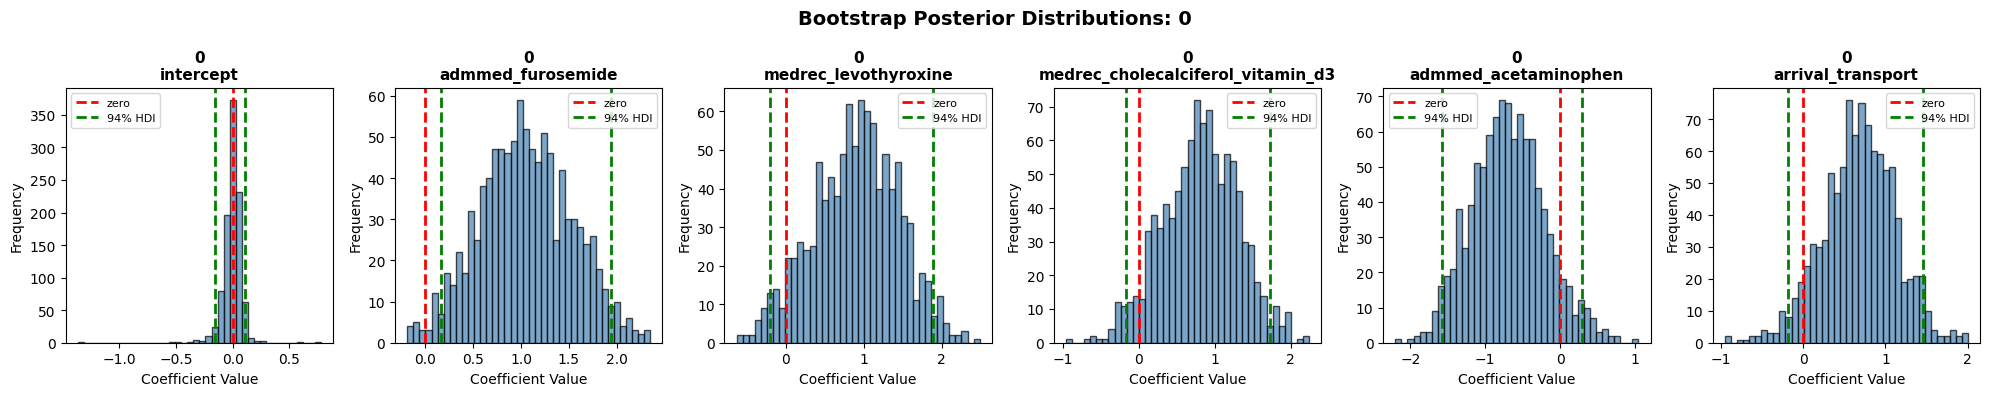

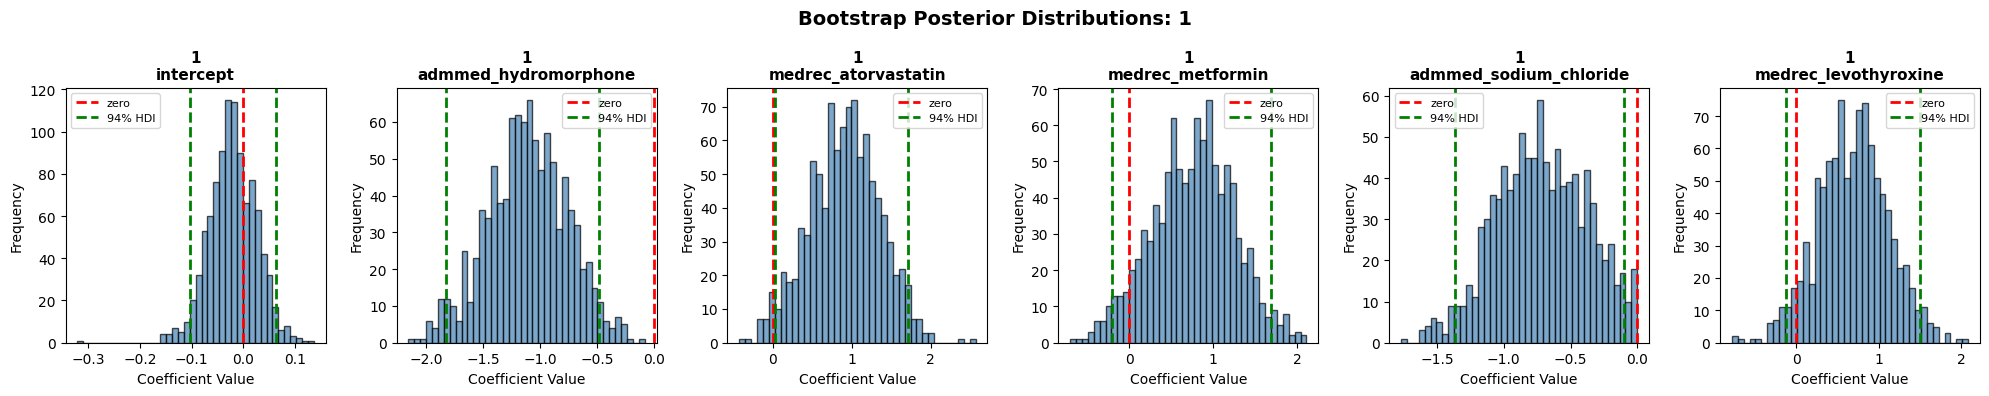

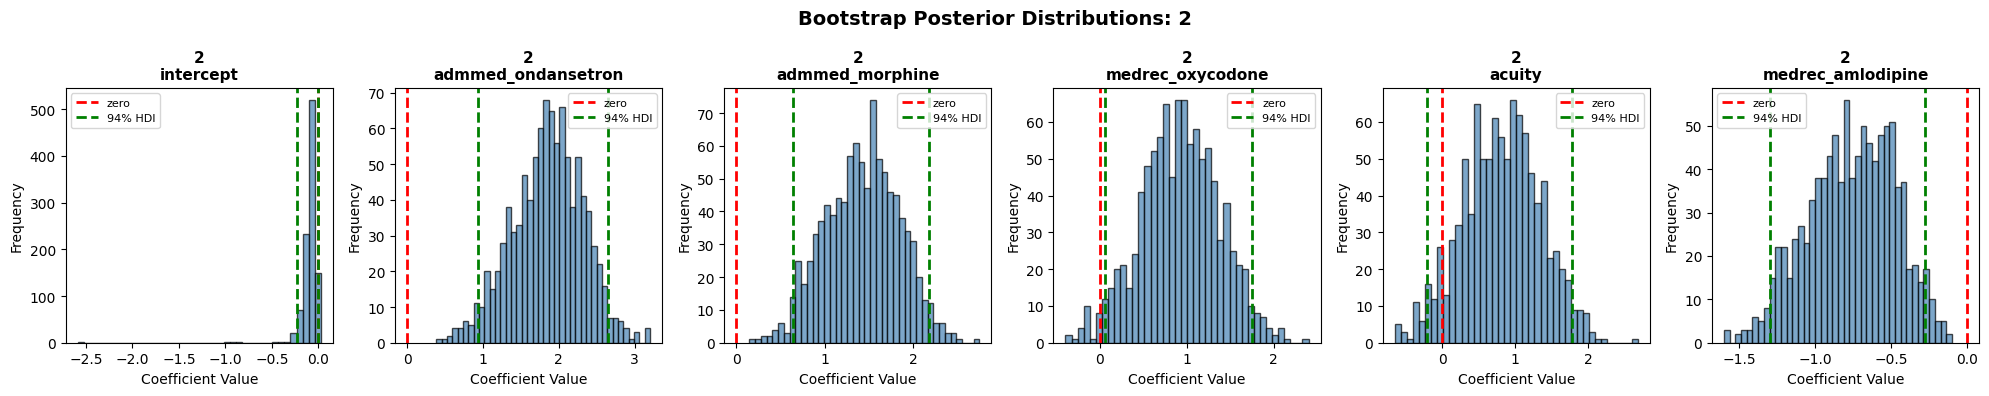

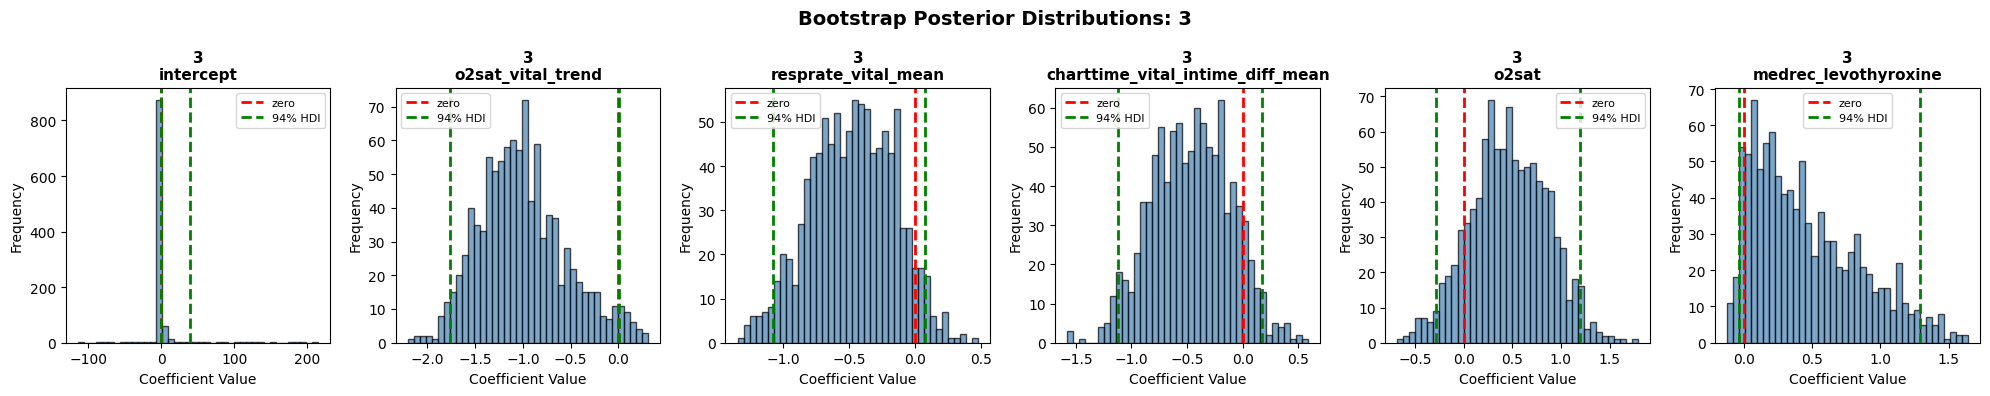

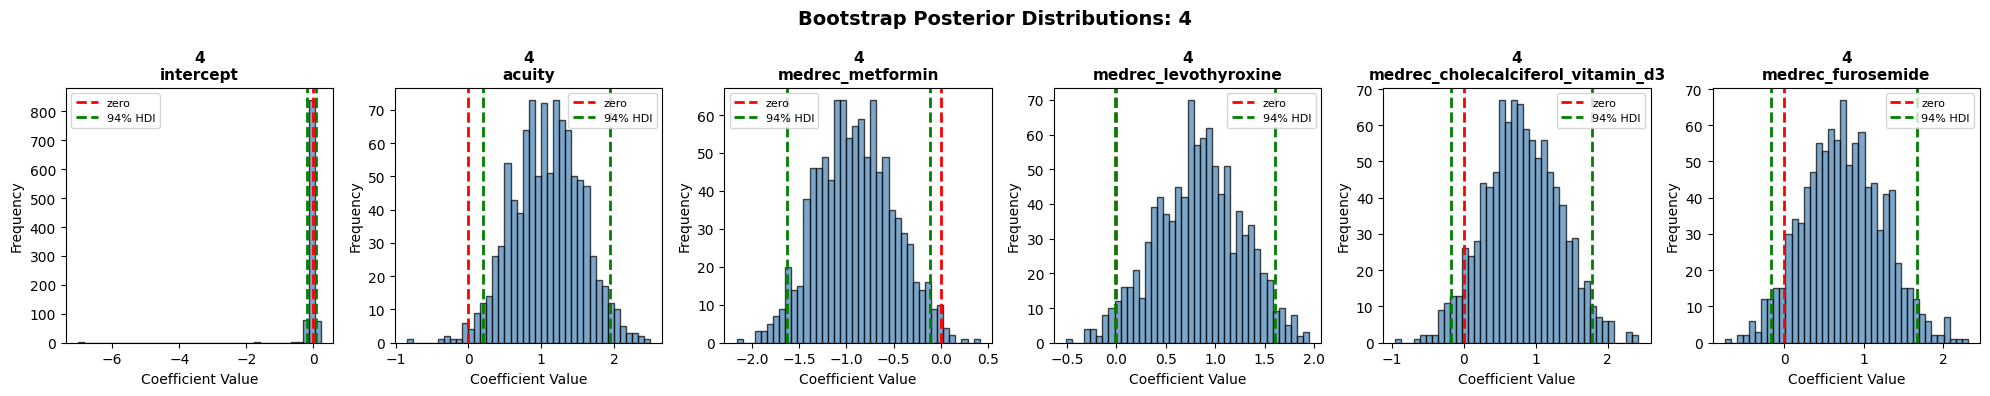

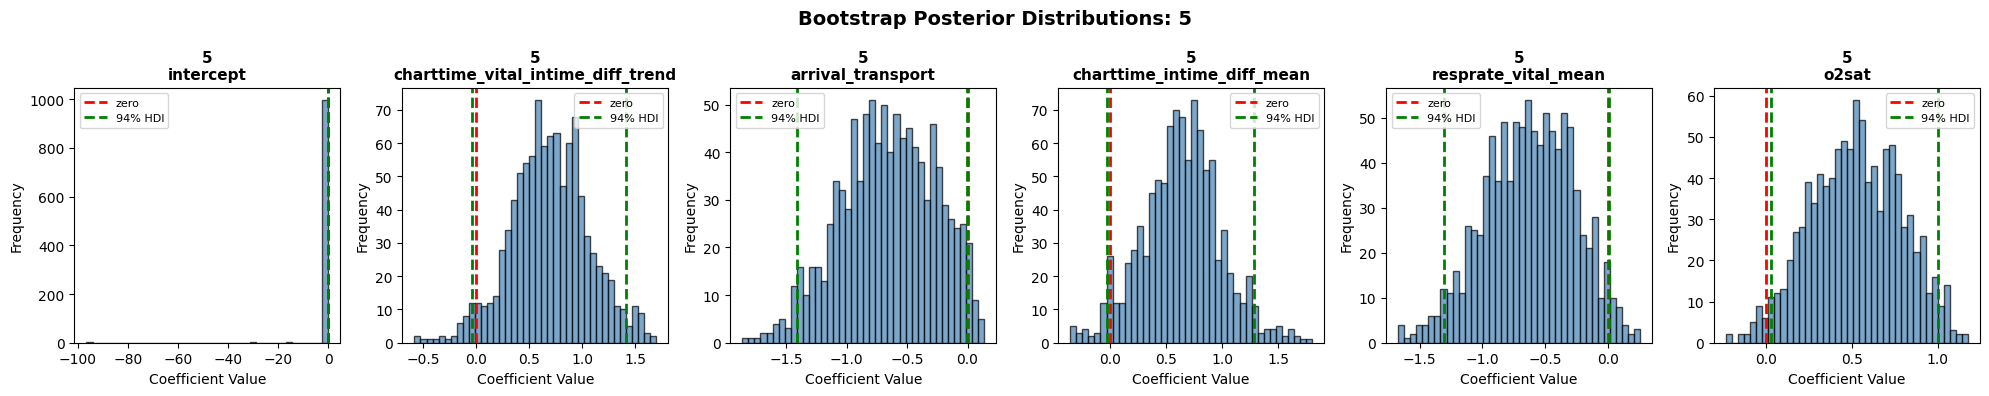

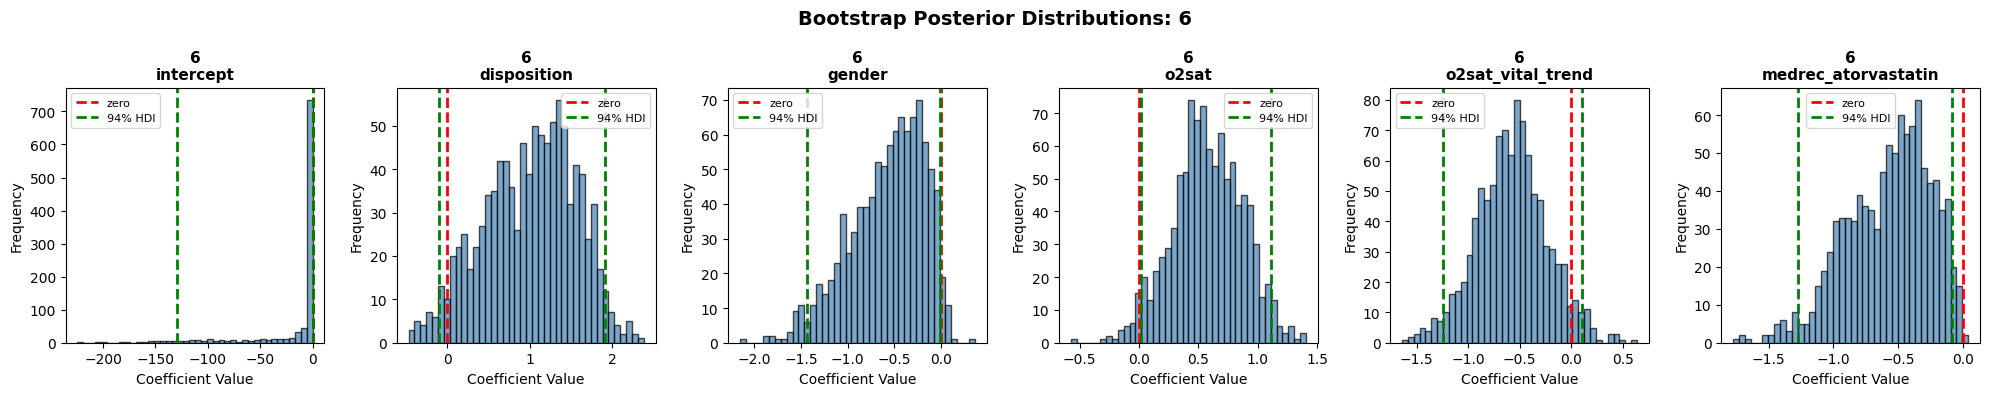

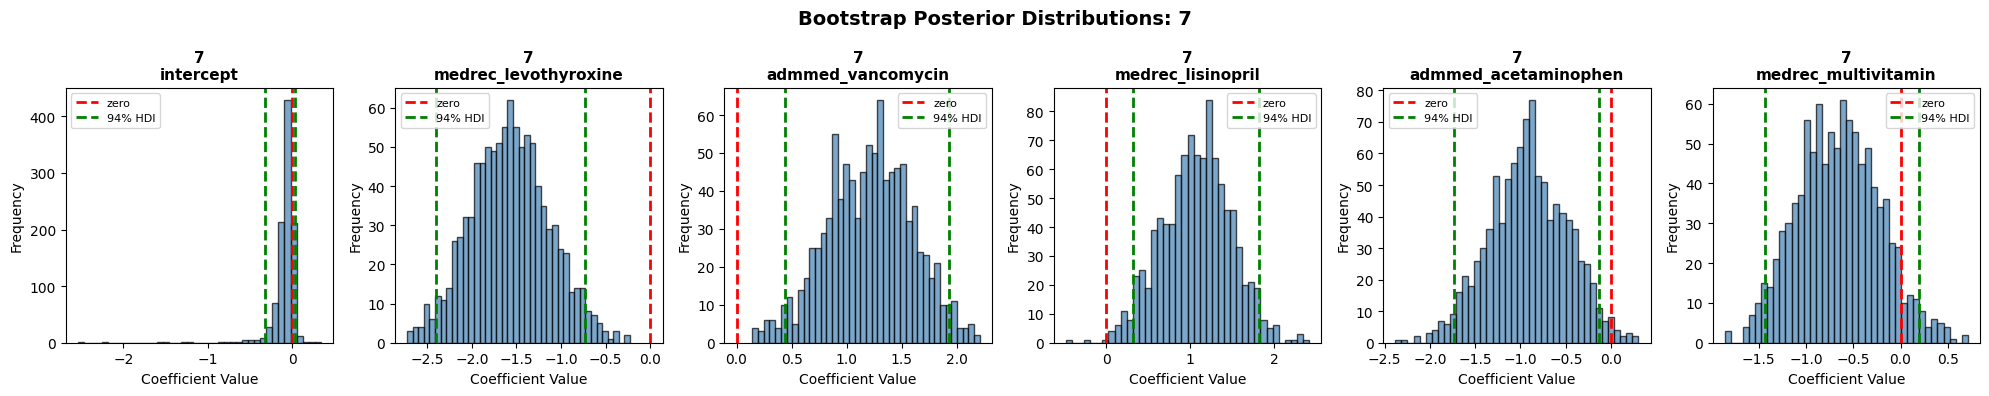

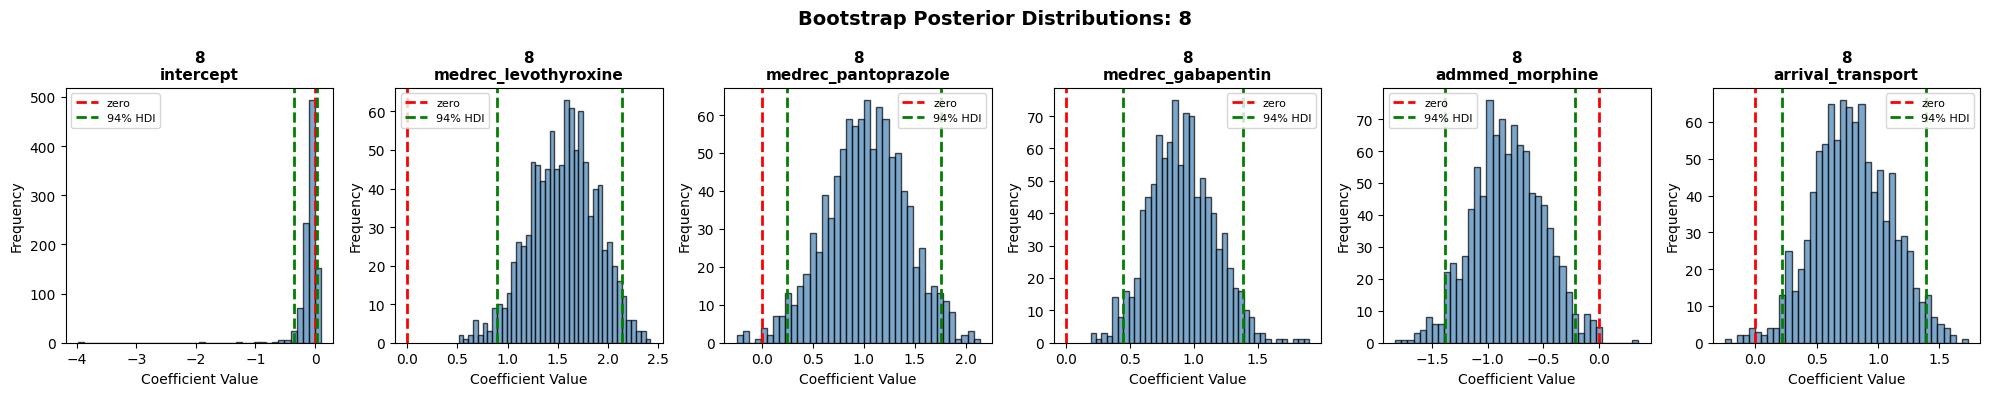

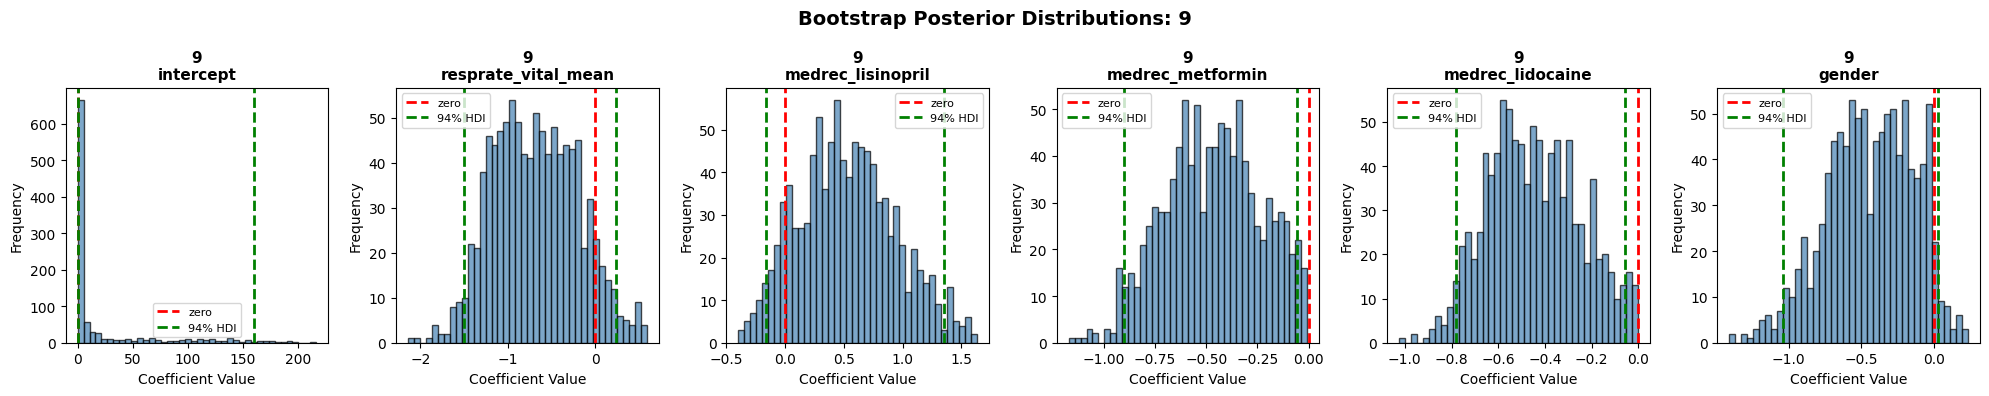

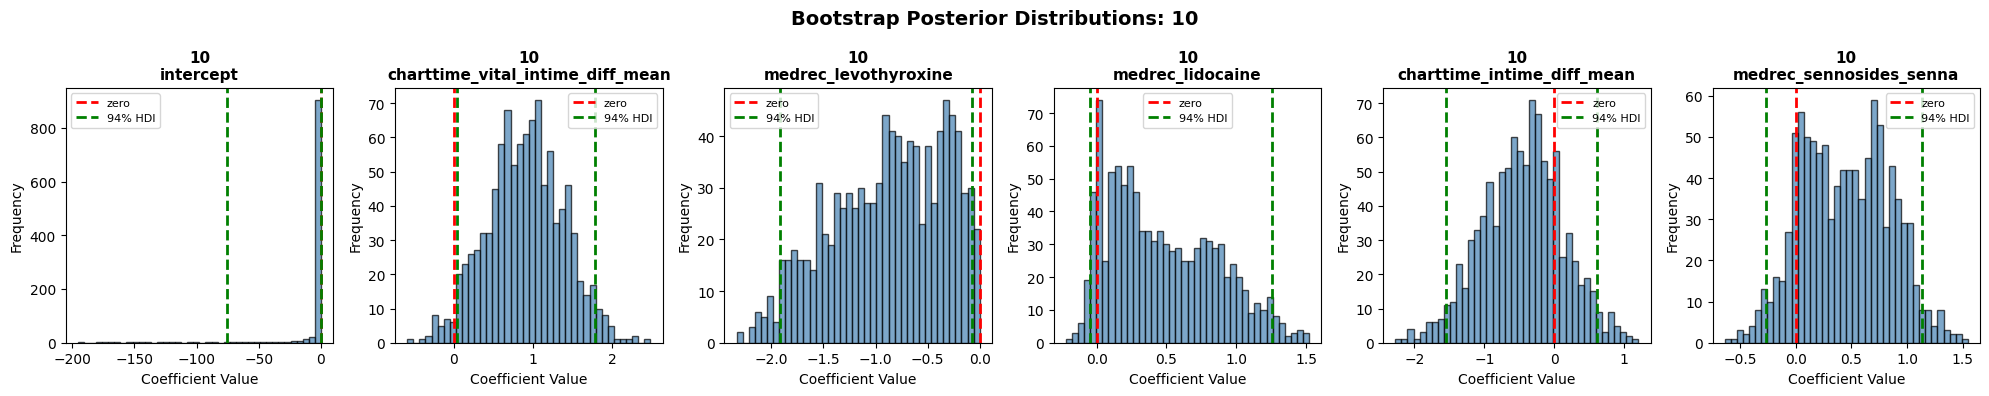


✓ Bootstrap Bayesian logistic regression complete.


In [21]:
# Bootstrap-based Bayesian logistic regression using scikit-learn
# Approximates Bayesian posterior via n_bootstrap=1000 fits on resampled training data

def sigmoid(x):
    """Sigmoid function: 1 / (1 + exp(-x))"""
    return 1 / (1 + np.exp(-x))

def fit_bayesian_lr(X_vals, y_vals, label_name, n_bootstrap=1000):
    """
    Fit LogisticRegression on n_bootstrap bootstrap samples.
    Returns array of shape (n_bootstrap, n_features + 1) where each row is
    [intercept, coef_1, coef_2, ...].
    Skips resamples with < 2 unique classes and replaces them.
    """
    n_samples, n_features = X_vals.shape
    coeff_samples = np.zeros((n_bootstrap, n_features + 1))
    
    for i in range(n_bootstrap):
        # Resample with replacement until we have >= 2 unique classes
        while True:
            idx = np.random.choice(n_samples, size=n_samples, replace=True)
            X_boot = X_vals[idx]
            y_boot = y_vals[idx]
            if len(np.unique(y_boot)) >= 2:
                break
        
        # Fit logistic regression on bootstrap sample
        lr = LogisticRegression(
            penalty='l2',
            C=1.0,
            solver='lbfgs',
            max_iter=1000,
            class_weight='balanced'
        )
        lr.fit(X_boot, y_boot)
        
        # Store intercept + coefficients
        coeff_samples[i, 0] = lr.intercept_[0]
        coeff_samples[i, 1:] = lr.coef_[0]
    
    return coeff_samples

bootstrap_traces = {}
labels = y_merged_df.columns

for label in labels:
    print(f"Fitting bootstrap LR for label: {label}")
    bootstrap_traces[label] = fit_bayesian_lr(X.values, y_merged_df[label].values, label)

# Summarize results
summary_rows = []
for label in labels:
    coeff_boot = bootstrap_traces[label]
    intercept_boot = coeff_boot[:, 0]
    coeff_boot_features = coeff_boot[:, 1:]
    
    # Mean intercept and coefficients across bootstrap draws
    intercept_mean = intercept_boot.mean()
    coeff_mean = coeff_boot_features.mean(axis=0)
    
    # Compute mean posterior probability across training rows
    logits = X.values @ coeff_mean + intercept_mean
    probs = sigmoid(logits)
    mean_prob = probs.mean()
    
    # 94% HDI for intercept (3rd to 97th percentile)
    hdi_lower = np.percentile(intercept_boot, 3)
    hdi_upper = np.percentile(intercept_boot, 97)
    hdi_width = hdi_upper - hdi_lower
    
    summary_rows.append({
        'label': label,
        'mean_posterior_probability': mean_prob,
        'intercept_94_hdi_width': hdi_width,
        'intercept_hdi_lower': hdi_lower,
        'intercept_hdi_upper': hdi_upper,
    })

summary_df = pd.DataFrame(summary_rows).sort_values('intercept_94_hdi_width', ascending=False)
print("\n=== Bootstrap Bayesian Logistic Regression Summary ===")
print(summary_df[['label', 'mean_posterior_probability', 'intercept_94_hdi_width']].to_string(index=False))

# Warning for HDI including zero
print("\n=== Warnings for Uncertain Intercepts ===")
for row in summary_rows:
    if row['intercept_hdi_lower'] <= 0 <= row['intercept_hdi_upper']:
        print(f"⚠️  label '{row['label']}' intercept 94% HDI includes zero "
              f"({row['intercept_hdi_lower']:.4f}, {row['intercept_hdi_upper']:.4f})")

# Plot bootstrap distributions
for label in labels:
    coeff_boot = bootstrap_traces[label]
    intercept_boot = coeff_boot[:, 0]
    coeff_boot_features = coeff_boot[:, 1:]
    
    # Find top 5 most influential features by absolute mean
    coeff_mean = coeff_boot_features.mean(axis=0)
    top5_idx = np.argsort(np.abs(coeff_mean))[::-1][:5]
    
    # Create figure with 6 subplots (intercept + top 5 features)
    fig, axes = plt.subplots(1, 6, figsize=(20, 4))
    fig.suptitle(f"Bootstrap Posterior Distributions: {label}", fontsize=14, fontweight='bold')
    
    # Plot intercept
    ax = axes[0]
    ax.hist(intercept_boot, bins=40, alpha=0.7, edgecolor='black', color='steelblue')
    ax.axvline(0, color='red', linestyle='--', linewidth=2, label='zero')
    hdi_lower = np.percentile(intercept_boot, 3)
    hdi_upper = np.percentile(intercept_boot, 97)
    ax.axvline(hdi_lower, color='green', linestyle='--', linewidth=2, label='94% HDI')
    ax.axvline(hdi_upper, color='green', linestyle='--', linewidth=2)
    ax.set_title(f"{label}\nintercept", fontsize=11, fontweight='bold')
    ax.set_xlabel('Coefficient Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    
    # Plot top 5 features
    for j, feat_idx in enumerate(top5_idx, start=1):
        ax = axes[j]
        feat_boot = coeff_boot_features[:, feat_idx]
        feature_name = X.columns[feat_idx] if hasattr(X, 'columns') else f"feat_{feat_idx}"
        
        ax.hist(feat_boot, bins=40, alpha=0.7, edgecolor='black', color='steelblue')
        ax.axvline(0, color='red', linestyle='--', linewidth=2, label='zero')
        hdi_lower = np.percentile(feat_boot, 3)
        hdi_upper = np.percentile(feat_boot, 97)
        ax.axvline(hdi_lower, color='green', linestyle='--', linewidth=2, label='94% HDI')
        ax.axvline(hdi_upper, color='green', linestyle='--', linewidth=2)
        ax.set_title(f"{label}\n{feature_name}", fontsize=11, fontweight='bold')
        ax.set_xlabel('Coefficient Value')
        ax.set_ylabel('Frequency')
        ax.legend(fontsize=8)
    
    plt.tight_layout()
    plt.show()

print("\n✓ Bootstrap Bayesian logistic regression complete.")

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

# Bootstrap-based Bayesian logistic regression using scikit-learn
# Approximates Bayesian posterior via n_bootstrap=1000 fits on resampled training data

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def fit_bayesian_lr(X_vals, y_vals, label_name, n_bootstrap=1000):
    n_samples, n_features = X_vals.shape
    coeff_samples = np.zeros((n_bootstrap, n_features + 1))
    
    for i in range(n_bootstrap):
        # Resample with replacement until we have >= 2 unique classes
        while True:
            idx = np.random.choice(n_samples, size=n_samples, replace=True)
            X_boot = X_vals[idx]
            y_boot = y_vals[idx]
            if len(np.unique(y_boot)) >= 2:
                break
        
        # Fit logistic regression on bootstrap sample
        lr = LogisticRegression(
            penalty='l2',
            C=1.0,
            solver='lbfgs',
            max_iter=1000,
            class_weight='balanced'
        )
        lr.fit(X_boot, y_boot)
        
        # Store intercept + coefficients
        coeff_samples[i, 0] = lr.intercept_[0]
        coeff_samples[i, 1:] = lr.coef_[0]
    
    return coeff_samples

bootstrap_traces = {}
labels = y_merged_df.columns

# 5-fold cross-validated F1 scores for Bootstrap Bayesian LR
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
bootstrap_cv_f1 = {}
labels = y_merged_df.columns

for label in labels:
    fold_scores = []
    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y_merged_df[label]), start=1):
        X_train_fold = X.iloc[train_idx] if hasattr(X, "iloc") else X[train_idx]  # preserve DataFrame indexing
        X_test_fold = X.iloc[test_idx] if hasattr(X, "iloc") else X[test_idx]
        y_train_fold = y_merged_df[label].iloc[train_idx].values if hasattr(y_merged_df[label], "iloc") else y_merged_df[label][train_idx]
        y_test_fold = y_merged_df[label].iloc[test_idx].values if hasattr(y_merged_df[label], "iloc") else y_merged_df[label][test_idx]

        betas = fit_bayesian_lr(X_train_fold.values, y_train_fold, label, n_bootstrap=500)
        intercepts = betas[:, 0]
        coef_samples = betas[:, 1:]

        probs = sigmoid(X_test_fold.values @ coef_samples.T + intercepts)
        probs = probs.mean(axis=1)
        y_pred = (probs >= 0.5).astype(int)

        fold_scores.append(f1_score(y_test_fold, y_pred, zero_division=0))

    bootstrap_cv_f1[label] = fold_scores

print("=== Bootstrap Bayesian LR Cross-Validated F1 Scores ===")
for label in labels:
    fold_scores = bootstrap_cv_f1[label]
    print(f"Label: {label}")
    print(f"{'Fold':<6} {'Bootstrap Bayesian LR F1':>28}")
    for i, score in enumerate(fold_scores, start=1):
        print(f"{i:<6} {score:>28.4f}")
    print("-" * 34)
    print(f"{'Mean':<6} {np.mean(fold_scores):>28.4f}")
    print(f"{'Std':<6} {np.std(fold_scores):>28.4f}")


=== Bootstrap Bayesian LR Cross-Validated F1 Scores ===
Label: cardiovascular
Fold       Bootstrap Bayesian LR F1
1                            0.0000
2                            0.0000
3                            0.0000
4                            0.2000
5                            0.0000
----------------------------------
Mean                         0.0400
Std                          0.0800
Label: diabetes & metabolic disorders
Fold       Bootstrap Bayesian LR F1
1                            0.2500
2                            0.2857
3                            0.1667
4                            0.4762
5                            0.4000
----------------------------------
Mean                         0.3157
Std                          0.1098
Label: gastrointestinal
Fold       Bootstrap Bayesian LR F1
1                            0.3077
2                            0.1667
3                            0.2500
4                            0.3077
5                            0.400

In [21]:
# Shape: (n_labels, n_folds)
scores = [
    [0.0000, 0.0000, 0.0000, 0.2000, 0.0000],  # cardiovascular
    [0.2500, 0.2857, 0.1667, 0.4762, 0.4000],  # diabetes
    [0.3077, 0.1667, 0.2500, 0.3077, 0.4000],  # gastrointestinal
    [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],  # hematology
    [0.3636, 0.4444, 0.4000, 0.2500, 0.4000],  # hypertension
    [0.0000, 0.0000, 0.0000, 0.0000, 0.5000],  # neurological
    [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],  # pulmonary
    [0.7143, 0.4444, 0.3077, 0.2222, 0.2222],  # sepsis
    [0.3636, 0.1667, 0.4615, 0.6667, 0.4444],  # symptoms
    [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],  # surgical_trauma
    [0.4000, 0.0000, 0.0000, 0.6667, 0.0000],  # other
]

scores = np.array(scores)
per_fold_macro = scores.mean(axis=0)   # average across labels per fold
print("Per-fold macro F1:", per_fold_macro.round(4))
print(f"Overall macro F1: {per_fold_macro.mean():.4f} ± {per_fold_macro.std():.4f}")

Per-fold macro F1: [0.2181 0.1371 0.1442 0.2536 0.2151]
Overall macro F1: 0.1936 ± 0.0454
